# Driver Performance Analysis

**Phase 3 — Analytics | F1 Data Platform**

SQL-first rewrite — all aggregation and transformation is done in DuckDB.
Python is used only for setup, charting, and the rolling average in Section 7
which has no clean SQL equivalent.

**Key questions:**
1. How do drivers compare on outright pace?
2. Who is most consistent lap-to-lap?
3. Who gains or loses the most positions in races?
4. How do teammates compare head-to-head?
5. Where do drivers stand in the championship?

**Data:** 2026 season — rounds queried dynamically at runtime.  
**Charts:** Matplotlib only — no Plotly.

## 0. Setup

In [7]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from dotenv import load_dotenv

load_dotenv(repo_root / ".env")

# Parameters 
SEASON  = 2026
DB_PATH = repo_root / "dbt" / "data" / "f1_local.duckdb"

# Matplotlib theme 
BG_DARK  = "#0f1117"
BG_PANEL = "#1a1a2e"
GRID_COL = "#2a2a3e"
TEXT_COL = "#e0e0e0"

plt.rcParams.update({
    "figure.facecolor":  BG_DARK,
    "axes.facecolor":    BG_PANEL,
    "axes.edgecolor":    GRID_COL,
    "axes.labelcolor":   TEXT_COL,
    "axes.grid":         True,
    "grid.color":        GRID_COL,
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "text.color":        TEXT_COL,
    "xtick.color":       TEXT_COL,
    "ytick.color":       TEXT_COL,
    "legend.facecolor":  BG_PANEL,
    "legend.edgecolor":  GRID_COL,
    "legend.labelcolor": TEXT_COL,
    "figure.dpi":        120,
})

# Team colour palette 
TEAM_COLORS = {
    "red_bull":          "#3671C6",
    "ferrari":           "#E8002D",
    "mercedes":          "#27F4D2",
    "mclaren":           "#FF8000",
    "aston_martin":      "#229971",
    "alpine":            "#FF87BC",
    "alpine_f1_team":    "#FF87BC",
    "haas_f1_team":      "#B6BABD",
    "rb":                "#6692FF",
    "rb_f1_team":        "#6692FF",
    "williams":          "#64C4FF",
    "kick_sauber":       "#52E252",
    "cadillac_f1_team":  "#C8A84B",
    "audi":              "#FF0000",
}
DEFAULT_COLOR = "#888888"  # fallback for unknown teams

print(f"Repo root : {repo_root}")
print(f"DB path   : {DB_PATH}")
print(f"Season    : {SEASON}")

Repo root : /Users/christiangrier/Documents/formula-1-data-project
DB path   : /Users/christiangrier/Documents/formula-1-data-project/dbt/data/f1_local.duckdb
Season    : 2026


In [8]:
# DuckDB connection — read-only 
con = duckdb.connect(str(DB_PATH), read_only=True)

gold_tables = con.execute(
    "SELECT table_name FROM information_schema.tables "
    "WHERE table_schema = 'gold' ORDER BY table_name"
).df()
print("Gold tables:")
print(gold_tables.to_string(index=False))

Gold tables:
                table_name
mart_constructor_standings
     mart_driver_standings
            mart_lap_times
            mart_pit_stops
         mart_race_results
     mart_telemetry_stints
        mart_tyre_strategy
              mart_weather


In [9]:
#  Discover loaded rounds 
rounds_loaded = con.execute(f"""
    SELECT DISTINCT round
    FROM gold.mart_race_results
    WHERE season = {SEASON}
    ORDER BY round
""").df()["round"].tolist()

latest_round = max(rounds_loaded)
print(f"Rounds loaded for {SEASON}: {rounds_loaded}")

Rounds loaded for 2026: [1, 2, 3]


## 2. Championship Standings

All aggregation done in SQL — Python only calls the chart.

In [10]:
#  Points after latest round 
standings_latest = con.execute(f"""
    SELECT
        abbreviation,
        constructor,
        championship_points,
        championship_position,
        wins
    FROM gold.mart_driver_standings
    WHERE season = {SEASON}
      AND round  = {latest_round}
    ORDER BY championship_position
""").df()

standings_latest

,abbreviation,constructor,championship_points,championship_position,wins
0,ANT,mercedes,72.0,1,2
1,RUS,mercedes,63.0,2,1
2,LEC,ferrari,49.0,3,0
3,HAM,ferrari,41.0,4,0
4,NOR,mclaren,25.0,5,0
5,PIA,mclaren,21.0,6,0
6,BEA,haas_f1_team,17.0,7,0
7,GAS,alpine_f1_team,15.0,8,0
8,VER,red_bull,12.0,9,0
9,LAW,rb_f1_team,10.0,10,0


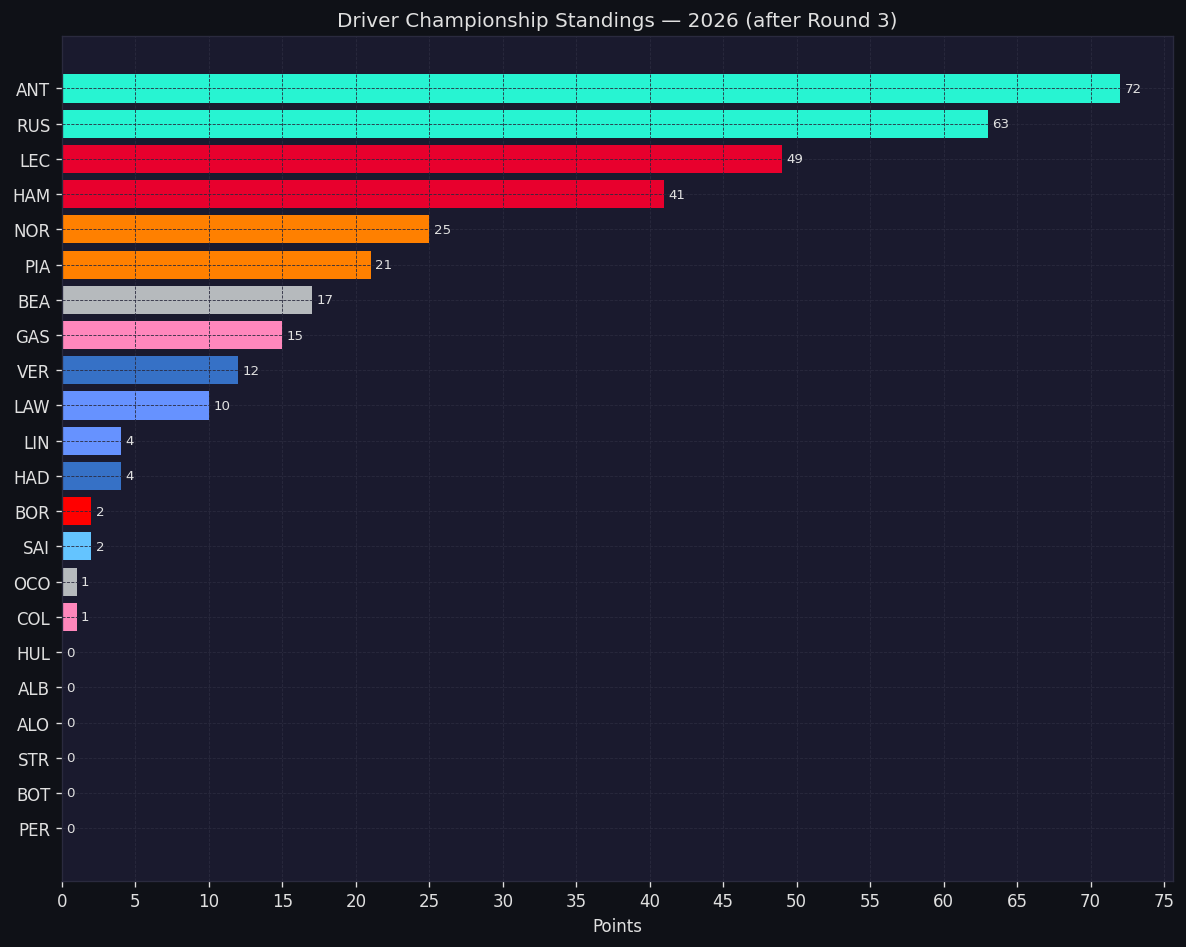

In [11]:
colors = [
    TEAM_COLORS.get(row["constructor"], DEFAULT_COLOR)
    for _, row in standings_latest.sort_values("championship_points").iterrows()
]

fig, ax = plt.subplots(figsize=(10, 8))
df_plot = standings_latest.sort_values("championship_points")

bars = ax.barh(df_plot["abbreviation"], df_plot["championship_points"],
               color=colors, edgecolor="none")

for bar, val in zip(bars, df_plot["championship_points"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}", va="center", fontsize=8, color=TEXT_COL)

ax.set_xlabel("Points")
ax.set_title(f"Driver Championship Standings — {SEASON} (after Round {latest_round})")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

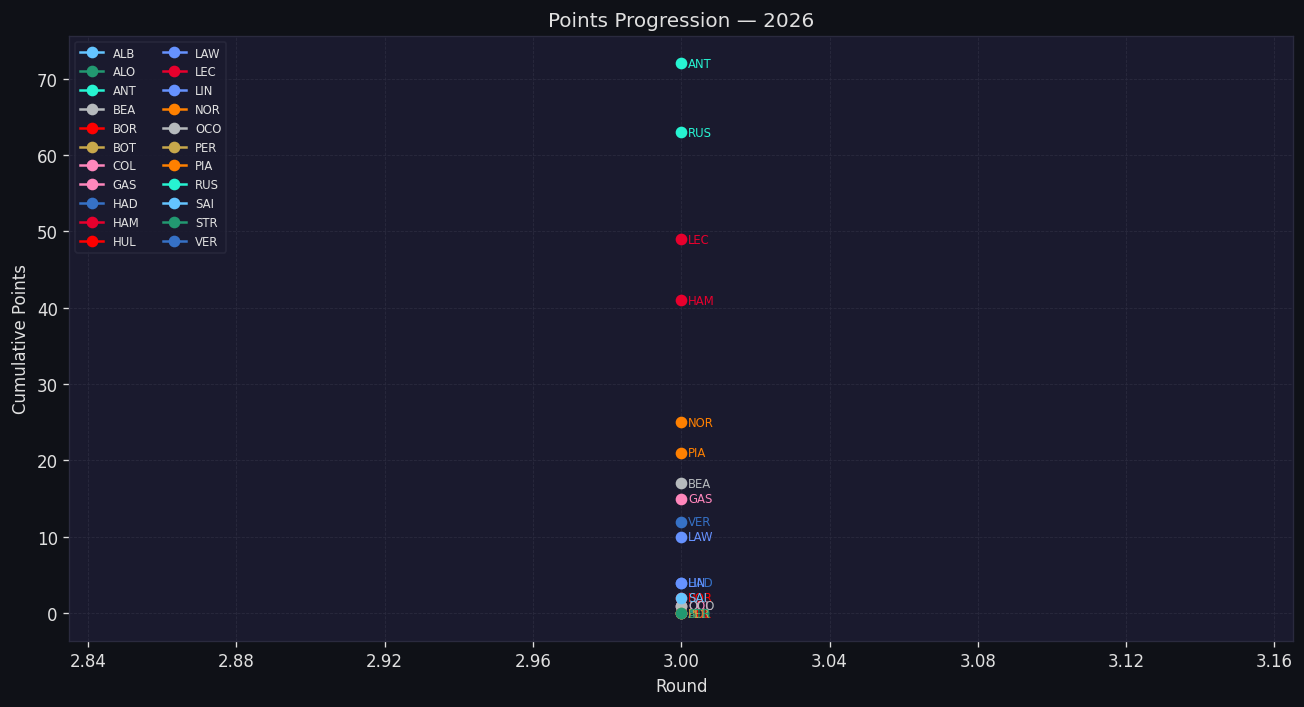

In [12]:
#  Points progression round by round 
if len(rounds_loaded) >= 2:
    standings_all = con.execute(f"""
        SELECT
            round,
            abbreviation,
            constructor,
            championship_points
        FROM gold.mart_driver_standings
        WHERE season = {SEASON}
        ORDER BY abbreviation, round
    """).df()

    fig, ax = plt.subplots(figsize=(11, 6))

    for driver, grp in standings_all.groupby("abbreviation"):
        color = TEAM_COLORS.get(grp["constructor"].iloc[0], DEFAULT_COLOR)
        ax.plot(grp["round"], grp["championship_points"],
                marker="o", linewidth=1.5, color=color, label=driver)
        ax.annotate(driver,
                    xy=(grp["round"].iloc[-1], grp["championship_points"].iloc[-1]),
                    xytext=(4, 0), textcoords="offset points",
                    fontsize=7, color=color, va="center")

    ax.set_xlabel("Round")
    ax.set_ylabel("Cumulative Points")
    ax.set_title(f"Points Progression — {SEASON}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping points progression — need at least 2 rounds.")

## 3. Race Pace

Median lap time and delta to fastest computed entirely in SQL using window functions.
No pandas groupby needed.

In [13]:
#  Pace summary — window function computes delta inline 
pace_summary = con.execute(f"""
    WITH filtered_laps AS (
        SELECT
            round,
            abbreviation,
            team_id,
            lap_time_seconds
        FROM gold.mart_lap_times
        WHERE season                = {SEASON}
          AND lap_number            > 1
          AND pit_out_time_seconds  IS NULL
    ),

    pace_per_driver AS (
        SELECT
            round,
            abbreviation,
            team_id,
            MEDIAN(lap_time_seconds)  AS median_lap_s,
            STDDEV(lap_time_seconds)  AS std_lap_s,
            COUNT(*)                  AS lap_count
        FROM filtered_laps
        GROUP BY round, abbreviation, team_id
    )

    SELECT
        round,
        abbreviation,
        team_id,
        ROUND(median_lap_s, 3)                                        AS median_lap_s,
        ROUND(std_lap_s, 3)                                           AS std_lap_s,
        lap_count,
        ROUND(
            median_lap_s - MIN(median_lap_s) OVER (PARTITION BY round), 3
        )                                                             AS delta_to_fastest_s
    FROM pace_per_driver
    ORDER BY round, delta_to_fastest_s
""").df()

pace_summary

,round,abbreviation,team_id,median_lap_s,std_lap_s,lap_count,delta_to_fastest_s
0,1,ANT,mercedes,83.072,7.771,56,0.000
1,1,RUS,mercedes,83.127,7.338,56,0.054
2,1,LEC,ferrari,83.320,7.521,56,0.247
3,1,HAM,ferrari,83.443,7.681,56,0.371
4,1,VER,red_bull,83.587,7.149,55,0.515
5,1,NOR,mclaren,83.784,7.407,55,0.712
6,1,BEA,haas,84.760,6.408,55,1.688
7,1,BOR,audi,84.820,7.059,54,1.748
8,1,LIN,rb,84.909,6.292,55,1.837
9,1,LAW,rb,85.254,6.682,54,2.182


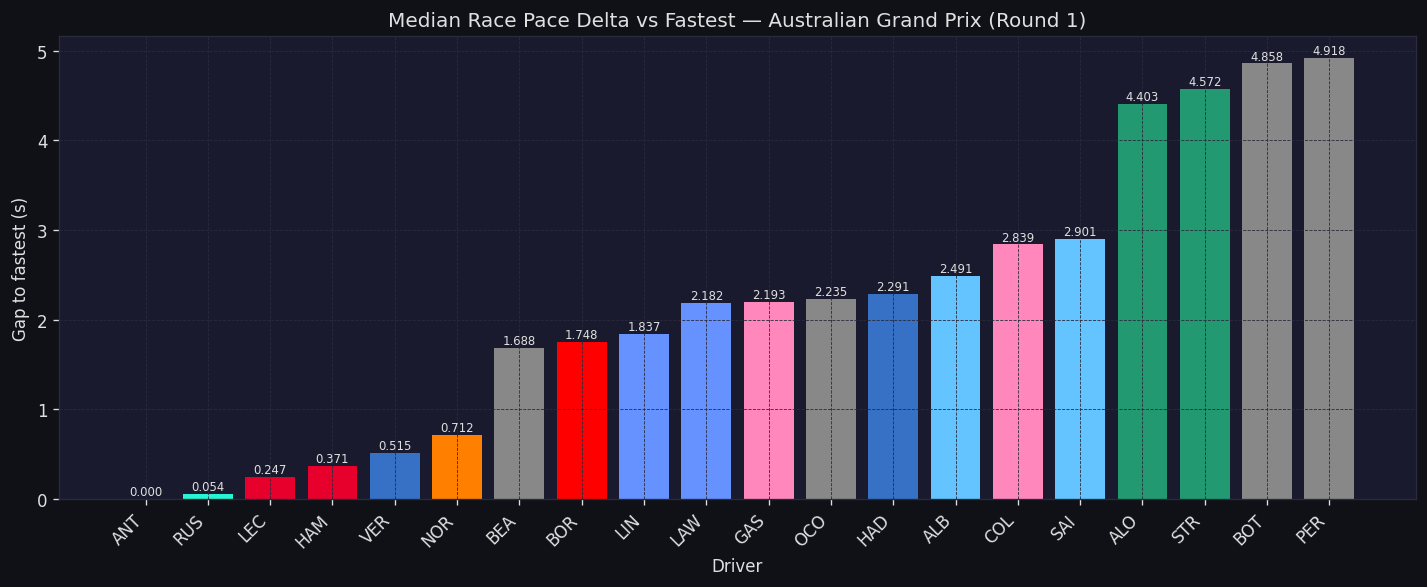

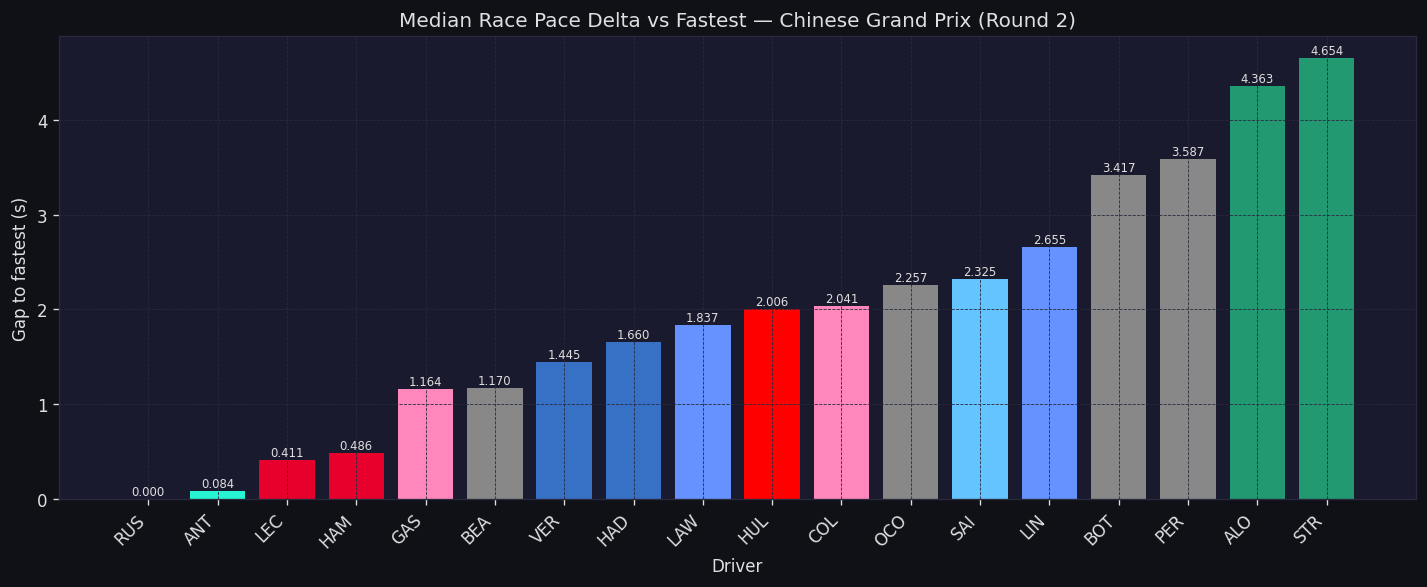

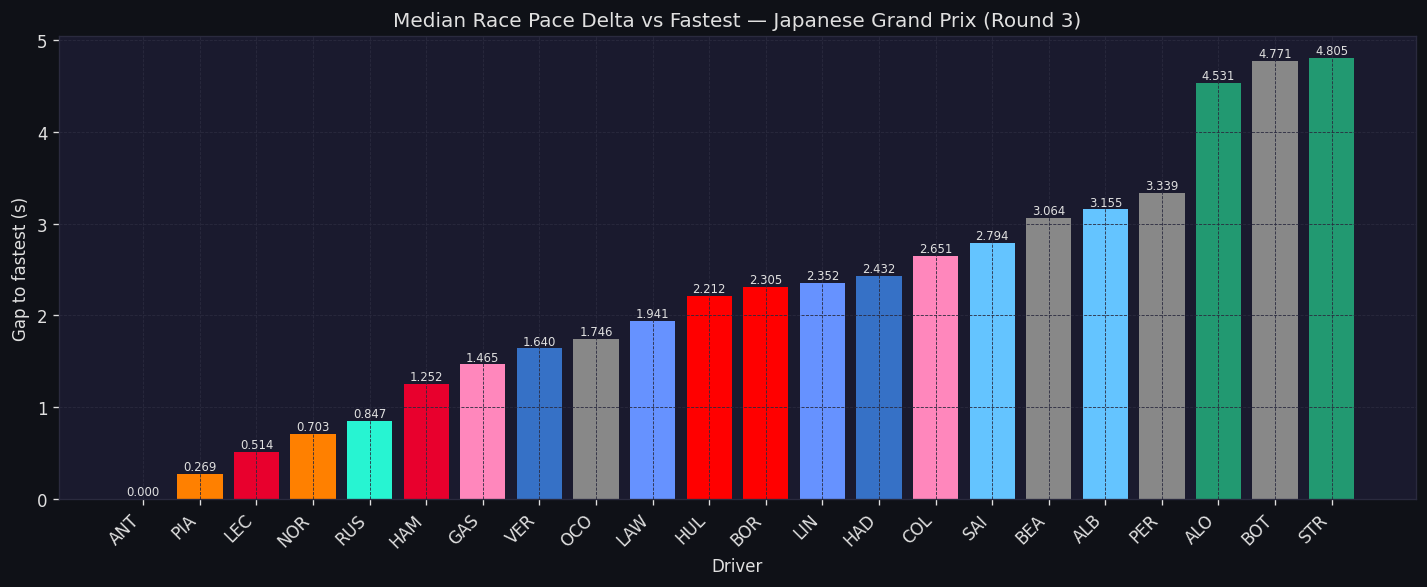

In [14]:
#  Pace delta vs fastest — per round 
race_names = con.execute(f"""
    SELECT DISTINCT round, race_name
    FROM gold.mart_race_results
    WHERE season = {SEASON}
    ORDER BY round
""").df().set_index("round")["race_name"].to_dict()

for rnd in sorted(rounds_loaded):
    df_rnd = pace_summary[pace_summary["round"] == rnd].copy()
    colors = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in df_rnd["team_id"]]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(df_rnd["abbreviation"], df_rnd["delta_to_fastest_s"],
                  color=colors, edgecolor="none")

    for bar, val in zip(bars, df_rnd["delta_to_fastest_s"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, color=TEXT_COL)

    ax.set_xlabel("Driver")
    ax.set_ylabel("Gap to fastest (s)")
    ax.set_title(f"Median Race Pace Delta vs Fastest — {race_names[rnd]} (Round {rnd})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Consistency

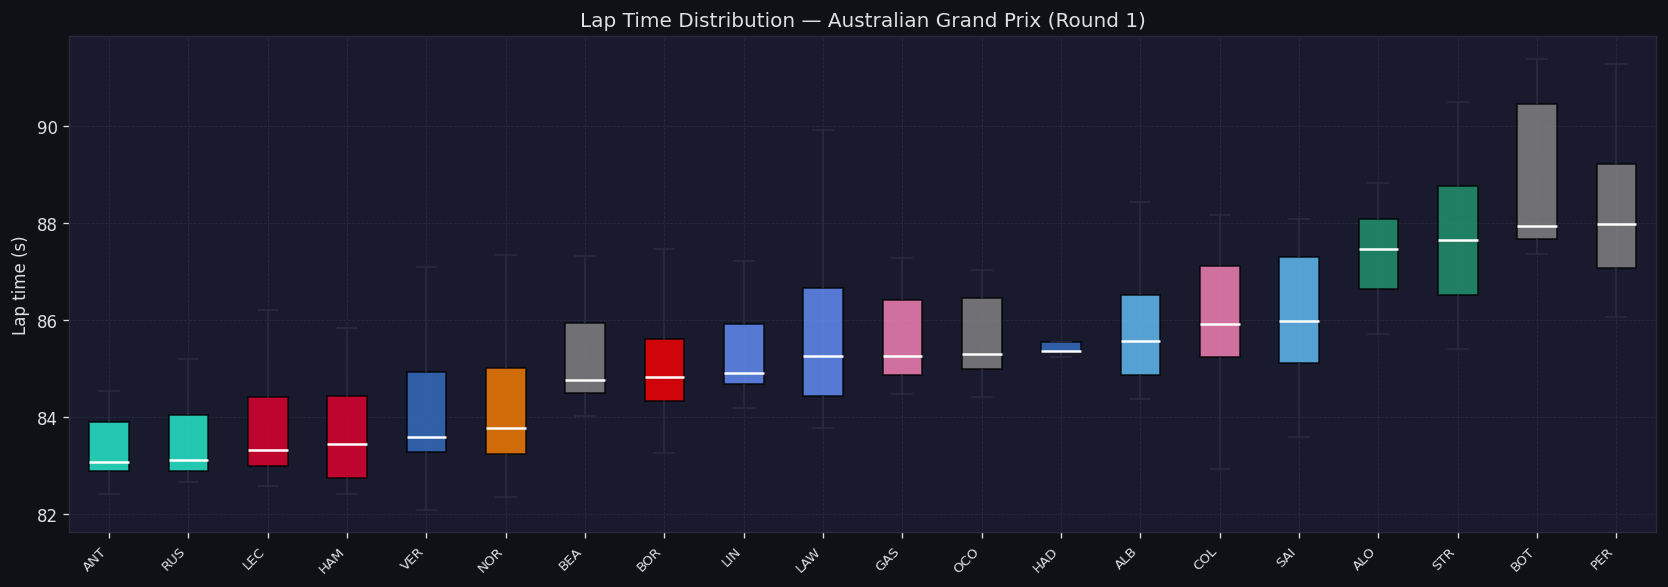

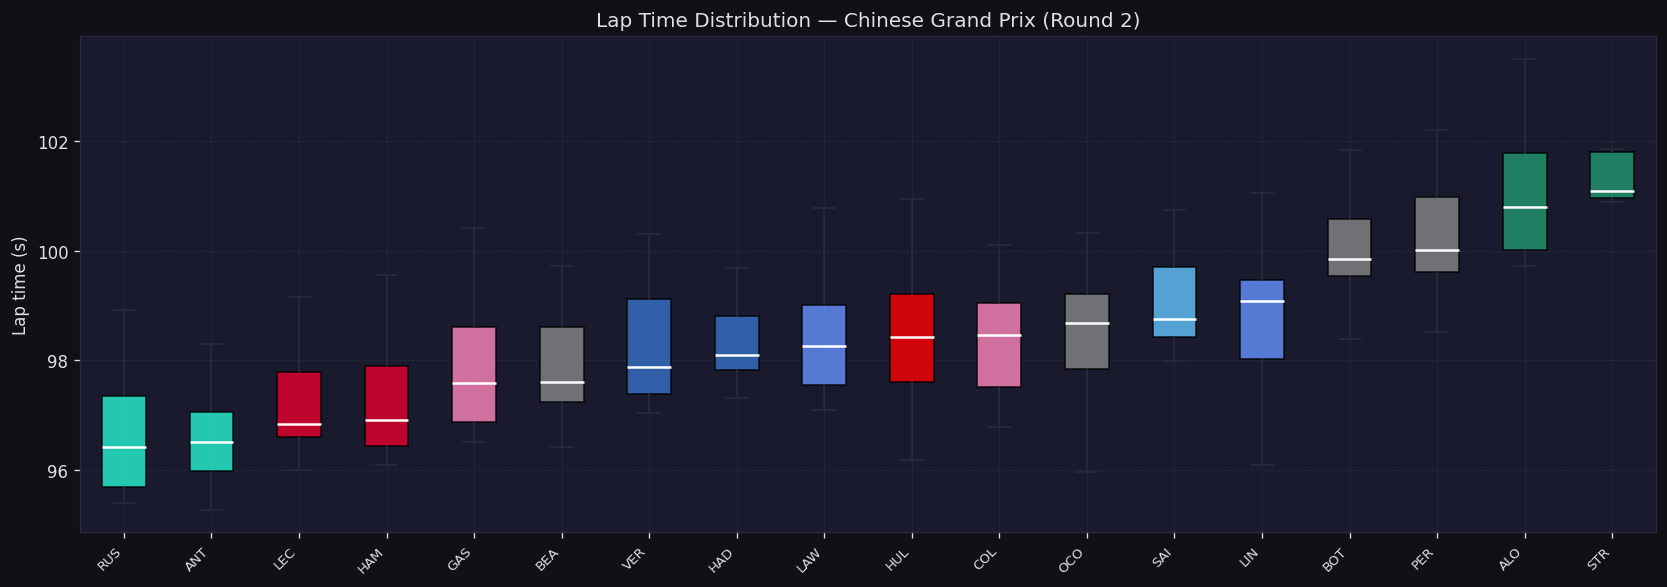

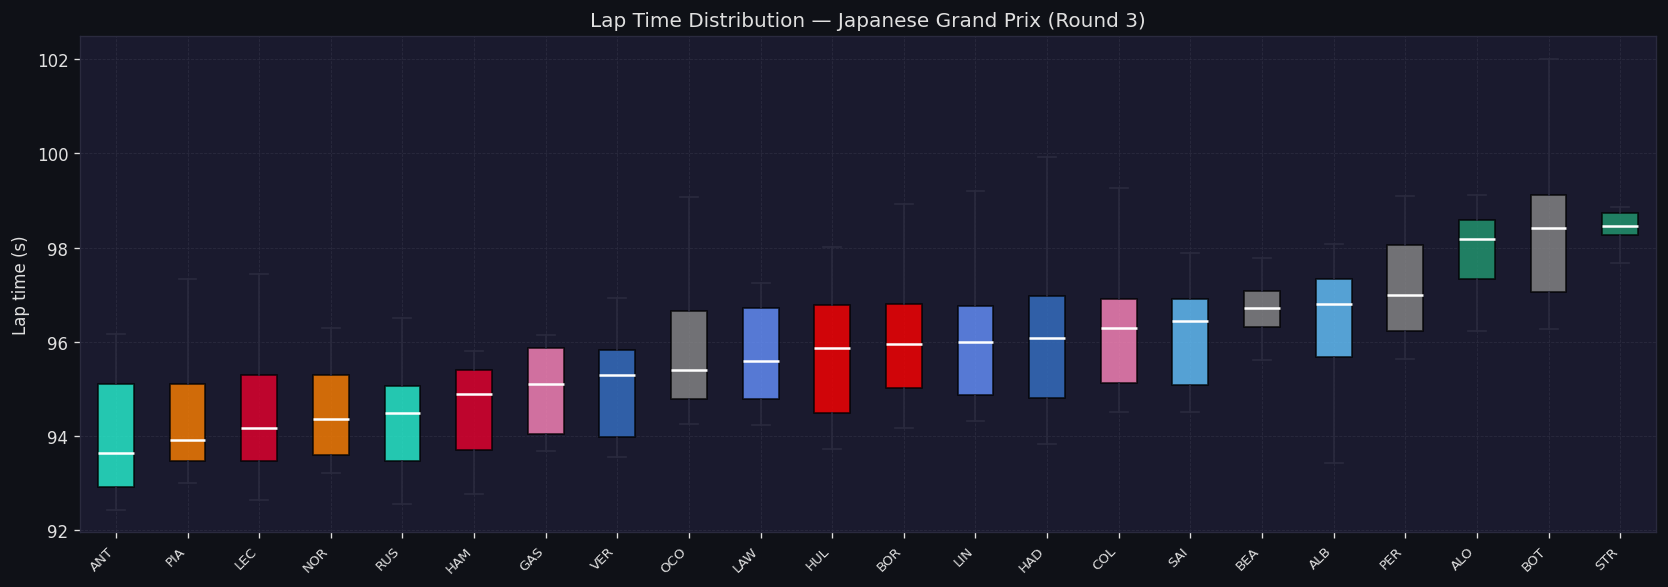

In [15]:
#  Lap time distribution — box plot ─
for rnd in sorted(rounds_loaded):
    lap_times_rnd = con.execute(f"""
        SELECT
            abbreviation,
            team_id,
            lap_time_seconds,
            MEDIAN(lap_time_seconds) OVER (PARTITION BY abbreviation) AS driver_median
        FROM gold.mart_lap_times
        WHERE season               = {SEASON}
          AND round                = {rnd}
          AND lap_number           > 1
          AND pit_out_time_seconds IS NULL
          AND lap_time_seconds     IS NOT NULL
        ORDER BY driver_median, abbreviation, lap_time_seconds
    """).df()

    if lap_times_rnd.empty:
        print(f"No lap data for round {rnd} — skipping.")
        continue

    driver_order = (
        lap_times_rnd.groupby("abbreviation")["lap_time_seconds"]
        .median()
        .sort_values()
        .index.tolist()
    )

    team_map = (
        lap_times_rnd.drop_duplicates("abbreviation")
        .set_index("abbreviation")["team_id"]
        .to_dict()
    )

    grouped = [
        lap_times_rnd[lap_times_rnd["abbreviation"] == d]["lap_time_seconds"].values
        for d in driver_order
    ]
    colors = [TEAM_COLORS.get(team_map.get(d, ""), DEFAULT_COLOR) for d in driver_order]

    fig, ax = plt.subplots(figsize=(14, 5))
    bp = ax.boxplot(grouped, patch_artist=True, showfliers=False,
                    medianprops=dict(color="white", linewidth=1.5))

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for element in ["whiskers", "caps"]:
        for item in bp[element]:
            item.set_color(GRID_COL)

    ax.set_xticks(range(1, len(driver_order) + 1))
    ax.set_xticklabels(driver_order, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Lap time (s)")
    ax.set_title(f"Lap Time Distribution — {race_names[rnd]} (Round {rnd})")
    plt.tight_layout()
    plt.show()

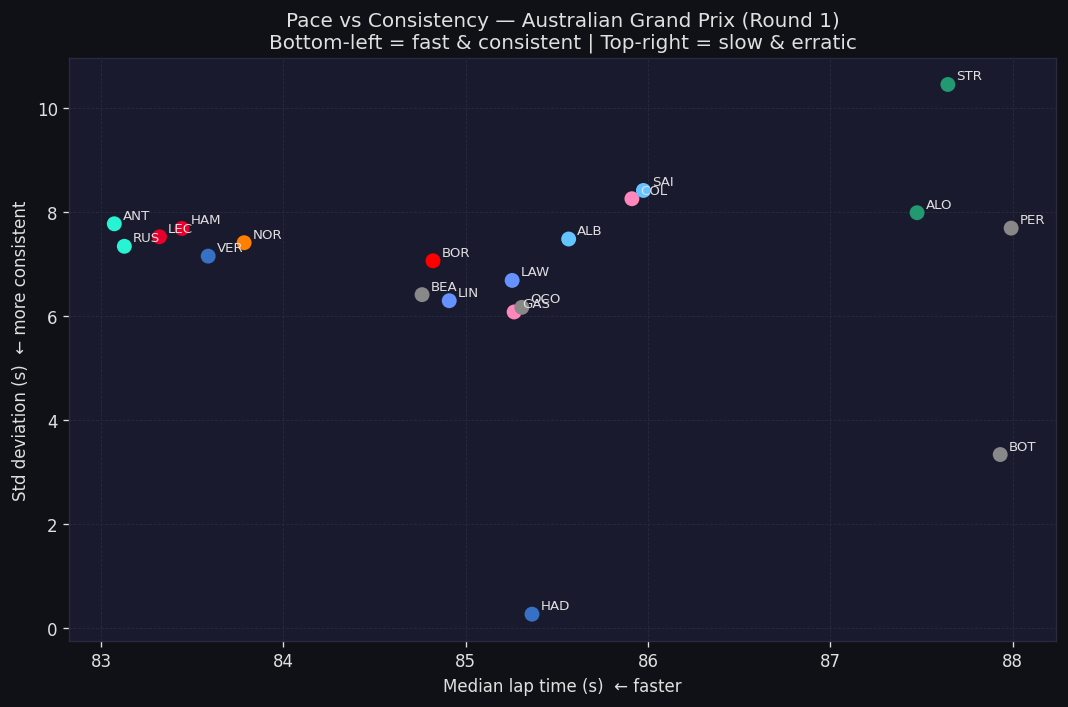

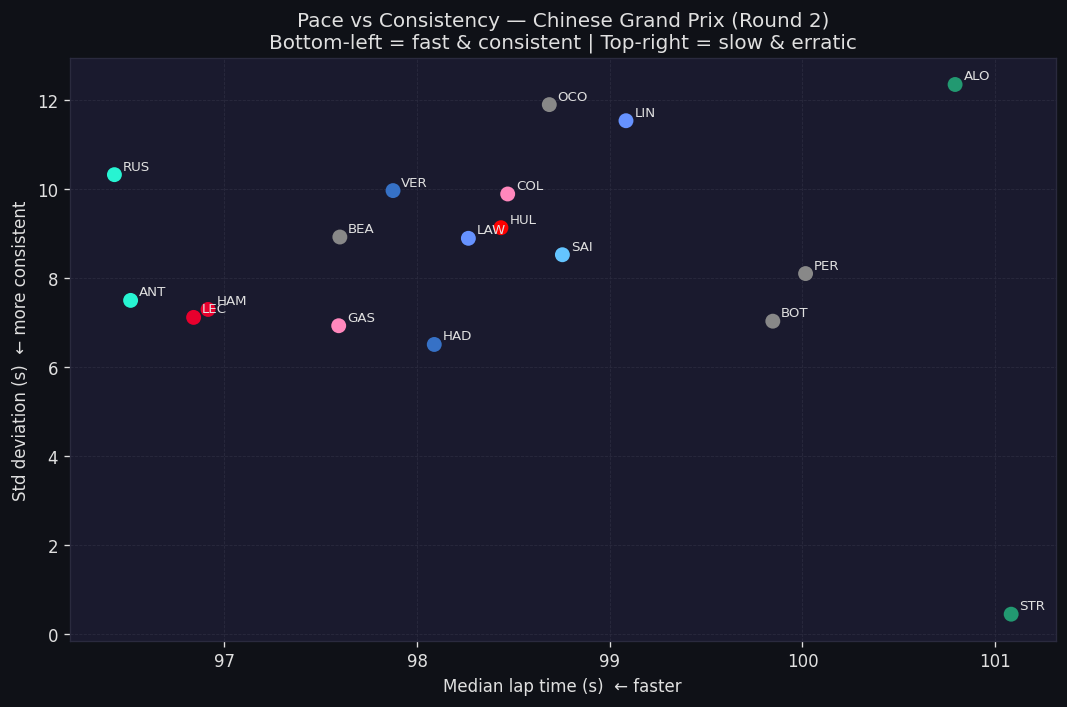

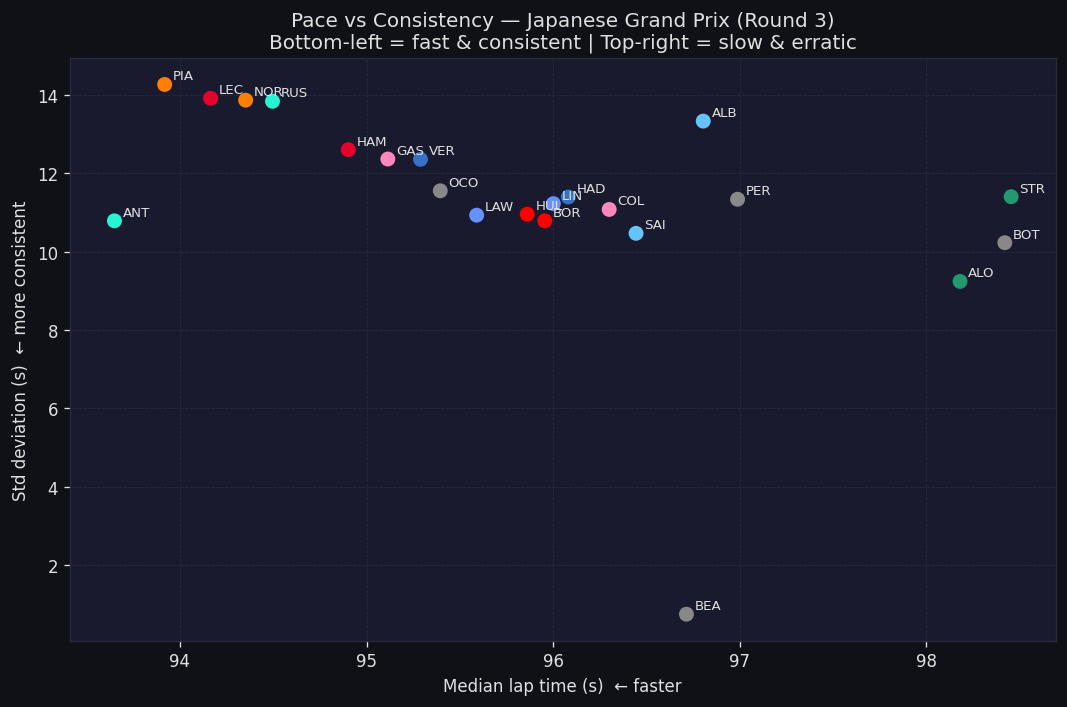

In [16]:
#  Pace vs Consistency scatter 
for rnd in sorted(rounds_loaded):
    df_rnd = pace_summary[pace_summary["round"] == rnd].copy()
    colors = [TEAM_COLORS.get(t, DEFAULT_COLOR) for t in df_rnd["team_id"]]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(df_rnd["median_lap_s"], df_rnd["std_lap_s"],
               c=colors, s=80, zorder=3, edgecolors="none")

    for _, row in df_rnd.iterrows():
        ax.annotate(row["abbreviation"],
                    xy=(row["median_lap_s"], row["std_lap_s"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=TEXT_COL)

    ax.set_xlabel("Median lap time (s)  ← faster")
    ax.set_ylabel("Std deviation (s)  ← more consistent")
    ax.set_title(
        f"Pace vs Consistency — {race_names[rnd]} (Round {rnd})\n"
        "Bottom-left = fast & consistent | Top-right = slow & erratic"
    )
    plt.tight_layout()
    plt.show()

## 5. Racecraft — Positions Gained / Lost

All aggregation in SQL including the net positions calculation.

In [17]:
#  Net positions gained — aggregated in SQL ─
racecraft_agg = con.execute(f"""
    SELECT
        abbreviation,
        constructor,
        COUNT(*)                                          AS races,
        SUM(grid_position - finish_position)              AS total_positions_gained,
        ROUND(AVG(finish_position), 2)                    AS avg_finish,
        ROUND(AVG(grid_position), 2)                      AS avg_grid
    FROM gold.mart_race_results
    WHERE season          = {SEASON}
      AND grid_position   IS NOT NULL
      AND finish_position IS NOT NULL
    GROUP BY abbreviation, constructor
    ORDER BY total_positions_gained DESC
""").df()

racecraft_agg

,abbreviation,constructor,races,total_positions_gained,avg_finish,avg_grid
0,SAI,williams,3,15.0,13.00,18.00
1,PER,cadillac_f1_team,3,10.0,16.00,19.33
2,VER,red_bull,3,9.0,10.00,13.00
3,STR,aston_martin,3,8.0,18.67,21.33
4,LAW,rb_f1_team,3,7.0,9.67,12.00
5,BOT,cadillac_f1_team,3,7.0,17.00,19.33
6,BEA,haas_f1_team,3,6.0,11.33,13.33
7,GAS,alpine_f1_team,3,5.0,7.67,9.33
8,HAM,ferrari,3,3.0,4.33,5.33
9,OCO,haas_f1_team,3,3.0,11.67,12.67


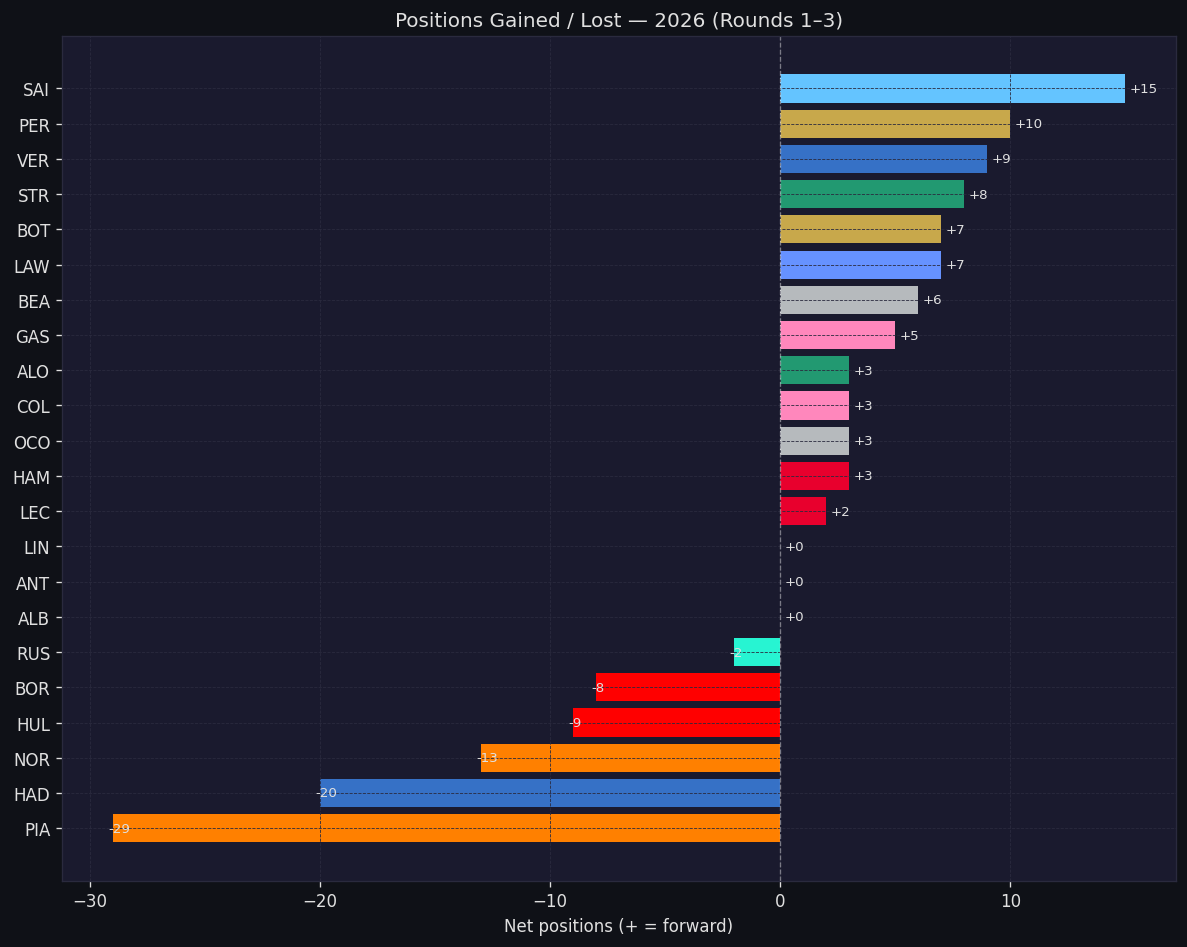

In [18]:
#  Positions gained bar chart ─
df_plot = racecraft_agg.sort_values("total_positions_gained")
colors  = [TEAM_COLORS.get(c, DEFAULT_COLOR) for c in df_plot["constructor"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_plot["abbreviation"], df_plot["total_positions_gained"],
               color=colors, edgecolor="none")

for bar, val in zip(bars, df_plot["total_positions_gained"]):
    xpos = bar.get_width() + (0.2 if val >= 0 else -0.2)
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.0f}", va="center", fontsize=8, color=TEXT_COL)

ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Net positions (+ = forward)")
ax.set_title(
    f"Positions Gained / Lost — {SEASON} "
    f"(Rounds {rounds_loaded[0]}–{rounds_loaded[-1]})"
)
plt.tight_layout()
plt.show()

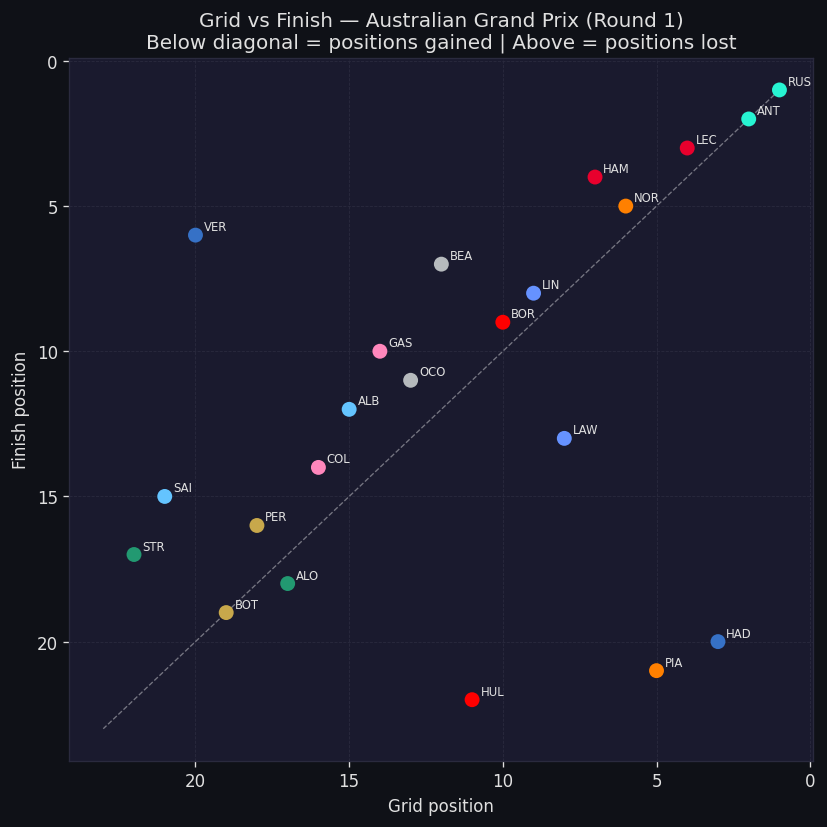

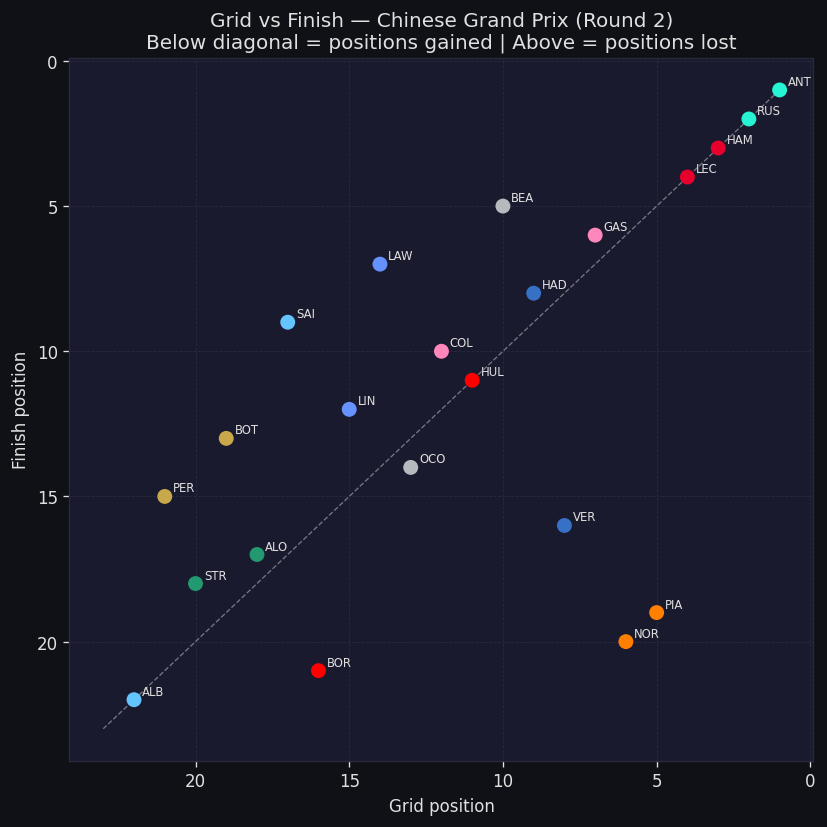

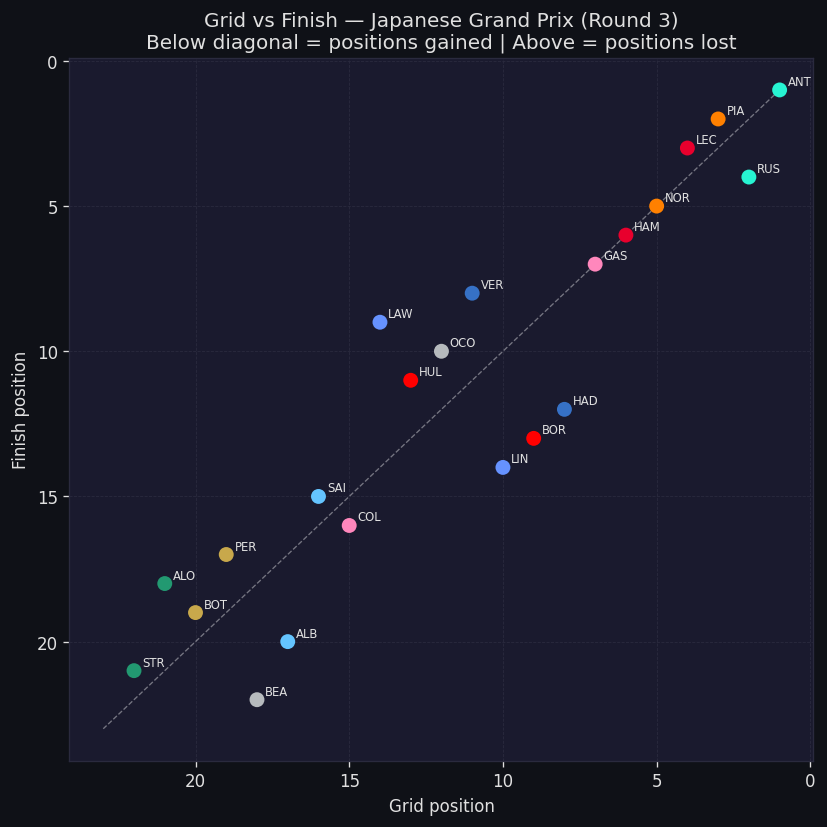

In [19]:
#  Grid vs Finish scatter — per round ─
for rnd in sorted(rounds_loaded):
    racecraft_rnd = con.execute(f"""
        SELECT
            abbreviation,
            constructor,
            grid_position,
            finish_position
        FROM gold.mart_race_results
        WHERE season          = {SEASON}
          AND round           = {rnd}
          AND grid_position   IS NOT NULL
          AND finish_position IS NOT NULL
    """).df()

    colors  = [TEAM_COLORS.get(c, DEFAULT_COLOR) for c in racecraft_rnd["constructor"]]
    max_pos = int(max(racecraft_rnd["grid_position"].max(),
                      racecraft_rnd["finish_position"].max())) + 1

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(racecraft_rnd["grid_position"], racecraft_rnd["finish_position"],
               c=colors, s=80, zorder=3, edgecolors="none")

    for _, row in racecraft_rnd.iterrows():
        ax.annotate(row["abbreviation"],
                    xy=(row["grid_position"], row["finish_position"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=7, color=TEXT_COL)

    ax.plot([1, max_pos], [1, max_pos], color="white",
            linewidth=0.8, linestyle="--", alpha=0.4)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel("Grid position")
    ax.set_ylabel("Finish position")
    ax.set_title(
        f"Grid vs Finish — {race_names[rnd]} (Round {rnd})\n"
        "Below diagonal = positions gained | Above = positions lost"
    )
    plt.tight_layout()
    plt.show()

## 6. Teammate Head-to-Head

Self-join and aggregation done entirely in SQL.

In [20]:
#  Finish position H2H — SQL self-join ─
h2h_summary = con.execute(f"""
    WITH pairs AS (
        SELECT
            a.round,
            a.constructor,
            a.abbreviation   AS driver_a,
            b.abbreviation   AS driver_b,
            a.finish_position AS pos_a,
            b.finish_position AS pos_b,
            CASE
                WHEN a.finish_position < b.finish_position THEN a.abbreviation
                ELSE b.abbreviation
            END              AS winner
        FROM gold.mart_race_results a
        JOIN gold.mart_race_results b
            ON  a.season      = b.season
            AND a.round       = b.round
            AND a.constructor = b.constructor
            AND a.abbreviation < b.abbreviation  -- canonical pair, no duplicates
        WHERE a.season          = {SEASON}
          AND a.finish_position IS NOT NULL
          AND b.finish_position IS NOT NULL
    )

    SELECT
        constructor,
        driver_a,
        driver_b,
        winner,
        COUNT(*) AS rounds_ahead
    FROM pairs
    GROUP BY constructor, driver_a, driver_b, winner
    ORDER BY constructor, rounds_ahead DESC
""").df()

h2h_summary

,constructor,driver_a,driver_b,winner,rounds_ahead
0,alpine_f1_team,COL,GAS,GAS,3
1,aston_martin,ALO,STR,ALO,2
2,aston_martin,ALO,STR,STR,1
3,audi,BOR,HUL,HUL,2
4,audi,BOR,HUL,BOR,1
5,cadillac_f1_team,BOT,PER,PER,2
6,cadillac_f1_team,BOT,PER,BOT,1
7,ferrari,HAM,LEC,LEC,2
8,ferrari,HAM,LEC,HAM,1
9,haas_f1_team,BEA,OCO,BEA,2


In [21]:
#  Teammate pace delta — SQL self-join on pace_summary 
pace_pairs = con.execute(f"""
    WITH constructor_map AS (
        SELECT DISTINCT
            round,
            abbreviation,
            constructor
        FROM gold.mart_race_results
        WHERE season = {SEASON}
    ),

    pace AS (
        SELECT
            l.round,
            l.abbreviation,
            c.constructor,
            MEDIAN(l.lap_time_seconds) AS median_lap_s
        FROM gold.mart_lap_times l
        JOIN constructor_map c
            ON  l.season       = {SEASON}
            AND l.round        = c.round
            AND l.abbreviation = c.abbreviation
        WHERE l.season               = {SEASON}
          AND l.lap_number           > 1
          AND l.pit_out_time_seconds IS NULL
        GROUP BY l.round, l.abbreviation, c.constructor
    )

    SELECT
        a.round,
        a.constructor,
        a.abbreviation                              AS driver_a,
        b.abbreviation                              AS driver_b,
        ROUND(a.median_lap_s, 3)                    AS pace_a,
        ROUND(b.median_lap_s, 3)                    AS pace_b,
        ROUND(ABS(a.median_lap_s - b.median_lap_s), 3) AS pace_delta_s,
        CASE
            WHEN a.median_lap_s < b.median_lap_s THEN a.abbreviation
            ELSE b.abbreviation
        END                                         AS faster_driver
    FROM pace a
    JOIN pace b
        ON  a.round       = b.round
        AND a.constructor = b.constructor
        AND a.abbreviation < b.abbreviation
    ORDER BY a.round, pace_delta_s DESC
""").df()

pace_pairs

,round,constructor,driver_a,driver_b,pace_a,pace_b,pace_delta_s,faster_driver
0,1,red_bull,HAD,VER,85.363,83.587,1.776,VER
1,1,alpine_f1_team,COL,GAS,85.911,85.265,0.646,GAS
2,1,haas_f1_team,BEA,OCO,84.760,85.307,0.547,BEA
3,1,williams,ALB,SAI,85.564,85.974,0.410,ALB
4,1,rb_f1_team,LAW,LIN,85.254,84.909,0.345,LIN
5,1,aston_martin,ALO,STR,87.475,87.644,0.169,ALO
6,1,ferrari,HAM,LEC,83.443,83.320,0.124,LEC
7,1,cadillac_f1_team,BOT,PER,87.931,87.991,0.060,BOT
8,1,mercedes,ANT,RUS,83.072,83.127,0.054,ANT
9,2,haas_f1_team,BEA,OCO,97.599,98.686,1.087,BEA


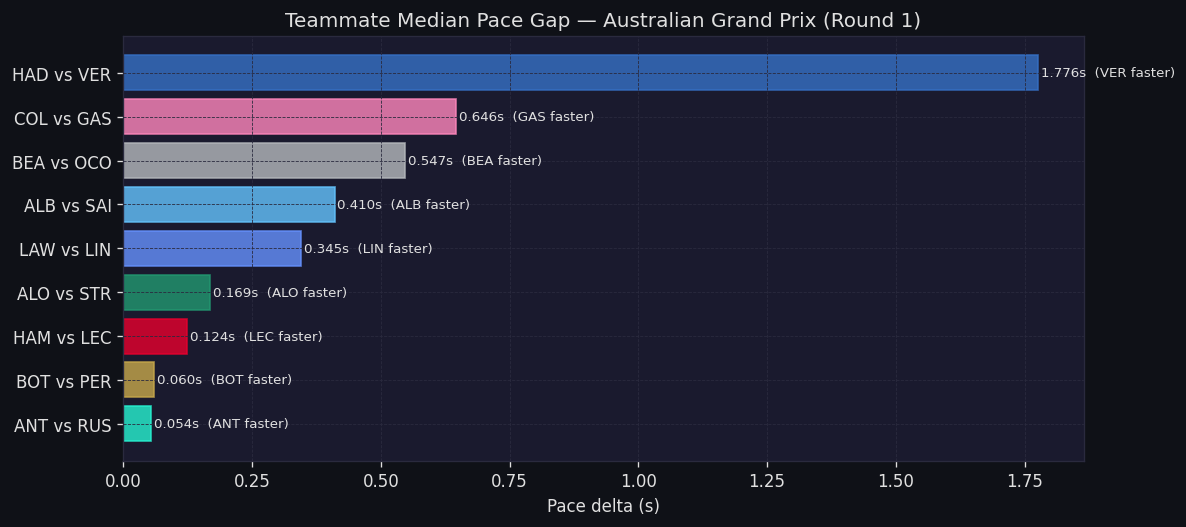

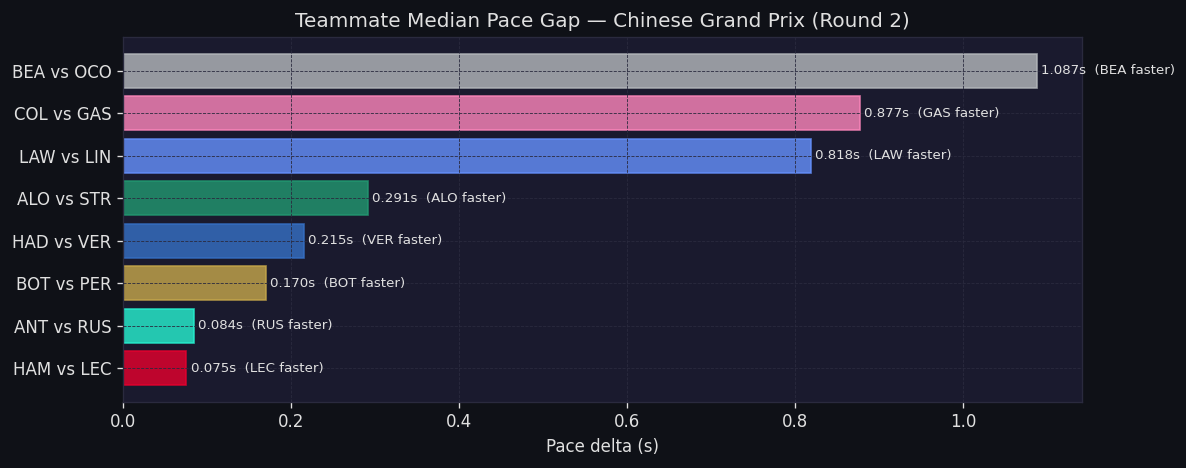

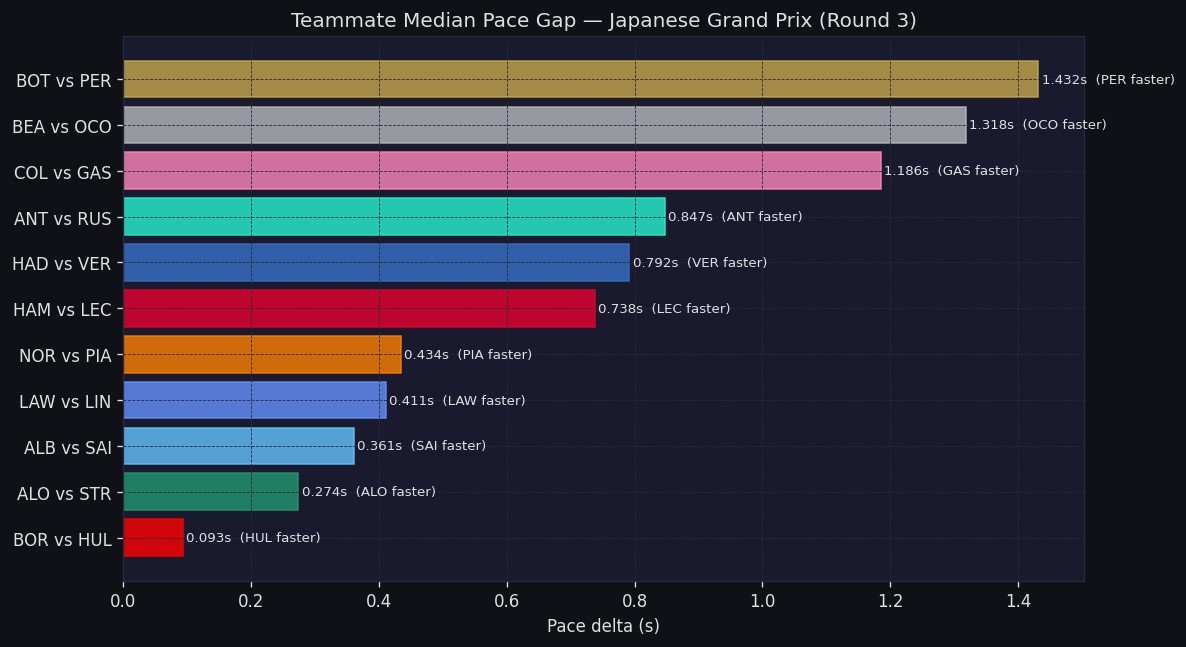

In [22]:
#  Pace delta bar chart — per round ─
for rnd in sorted(rounds_loaded):
    df_rnd = pace_pairs[pace_pairs["round"] == rnd].copy()
    df_rnd["matchup"] = df_rnd["driver_a"] + " vs " + df_rnd["driver_b"]
    df_rnd = df_rnd.sort_values("pace_delta_s", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_rnd) * 0.5)))
    bars = ax.barh(df_rnd["matchup"], df_rnd["pace_delta_s"],
                   color="#888888", edgecolor="none", alpha=0.8)

    for bar, (_, row) in zip(bars, df_rnd.iterrows()):
        color = TEAM_COLORS.get(
            pace_pairs[pace_pairs["driver_a"] == row["faster_driver"]]["constructor"].values[0]
            if row["faster_driver"] == row["driver_a"]
            else pace_pairs[pace_pairs["driver_b"] == row["faster_driver"]]["constructor"].values[0],
            DEFAULT_COLOR
        )
        bar.set_color(color)
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{row['pace_delta_s']:.3f}s  ({row['faster_driver']} faster)",
                va="center", fontsize=8, color=TEXT_COL)

    ax.set_xlabel("Pace delta (s)")
    ax.set_title(f"Teammate Median Pace Gap — {race_names[rnd]} (Round {rnd})")
    plt.tight_layout()
    plt.show()

## 7. Race Pace Evolution

Raw laps loaded from SQL. Rolling average stays in pandas — no clean SQL equivalent
for a per-group sliding window on ordered rows in DuckDB.

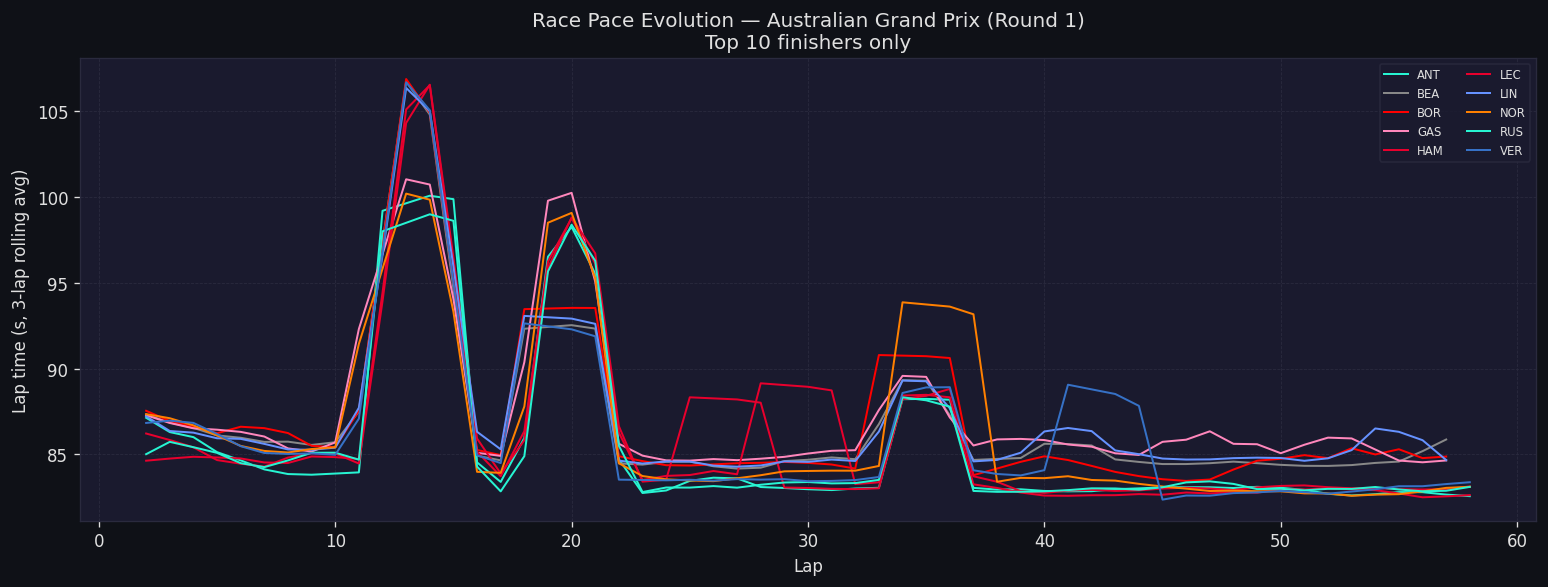

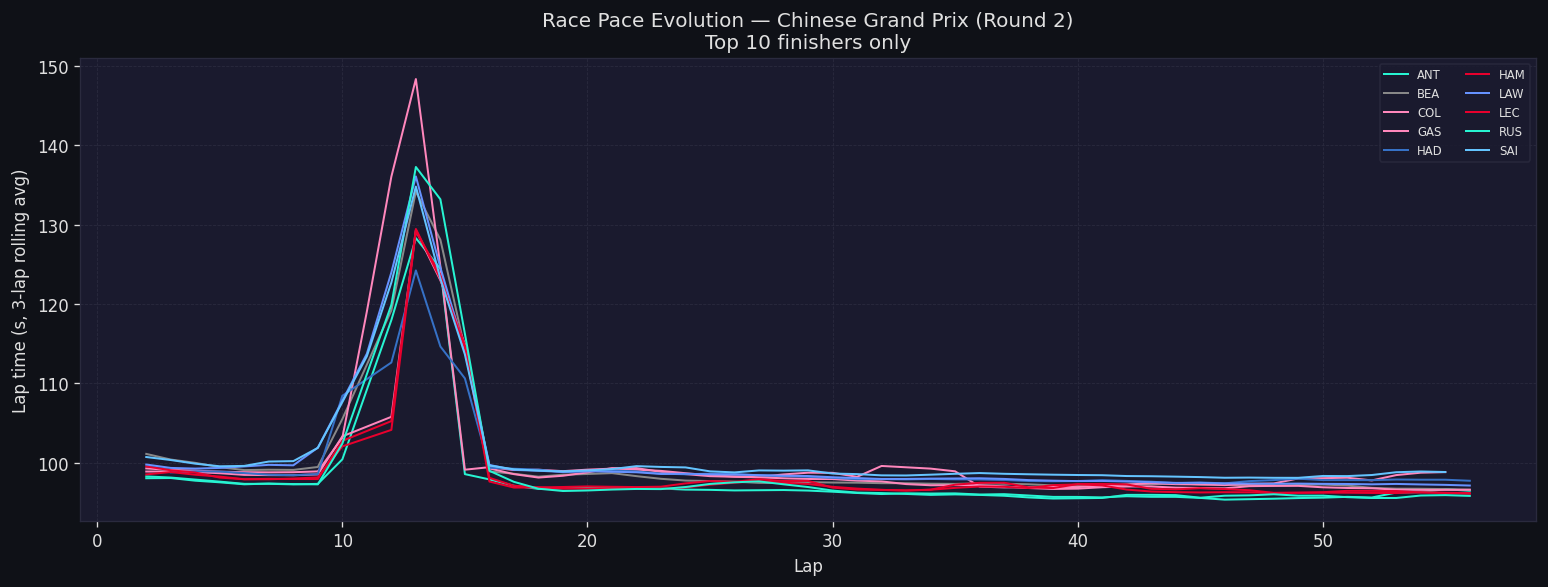

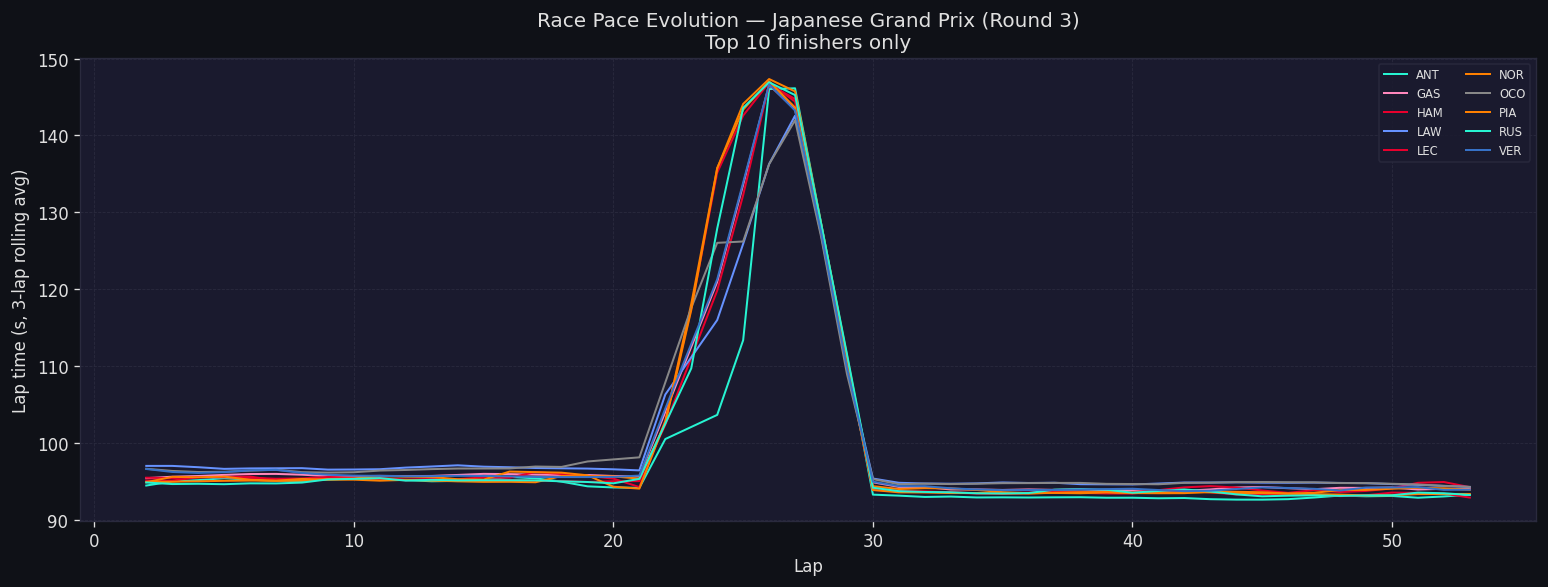

In [23]:
#  Lap time evolution — top 10 finishers, 3-lap rolling average 
for rnd in sorted(rounds_loaded):
    lap_evolution = con.execute(f"""
        WITH top10 AS (
            SELECT abbreviation
            FROM gold.mart_race_results
            WHERE season          = {SEASON}
              AND round           = {rnd}
              AND finish_position <= 10
        )

        SELECT
            l.abbreviation,
            l.team_id,
            l.lap_number,
            l.lap_time_seconds
        FROM gold.mart_lap_times l
        JOIN top10 t ON l.abbreviation = t.abbreviation
        WHERE l.season               = {SEASON}
          AND l.round                = {rnd}
          AND l.lap_number           > 1
          AND l.pit_out_time_seconds IS NULL
        ORDER BY l.abbreviation, l.lap_number
    """).df()

    lap_evolution["rolling_avg"] = (
        lap_evolution
        .groupby("abbreviation")["lap_time_seconds"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

    fig, ax = plt.subplots(figsize=(13, 5))

    for driver, grp in lap_evolution.groupby("abbreviation"):
        color = TEAM_COLORS.get(grp["team_id"].iloc[0], DEFAULT_COLOR)
        ax.plot(grp["lap_number"], grp["rolling_avg"],
                linewidth=1.2, color=color, label=driver)

    ax.set_xlabel("Lap")
    ax.set_ylabel("Lap time (s, 3-lap rolling avg)")
    ax.set_title(
        f"Race Pace Evolution — {race_names[rnd]} (Round {rnd})\n"
        "Top 10 finishers only"
    )
    ax.legend(fontsize=7, ncol=2, loc="upper right")
    plt.tight_layout()
    plt.show()

## 8. Driver Scorecard

Single CTE query assembles all metrics — no pandas merges needed.

In [24]:
#  Season scorecard — one query with CTEs 
scorecard = con.execute(f"""
    WITH race_summary AS (
        SELECT
            abbreviation,
            constructor,
            COUNT(*)                                              AS races,
            SUM(CASE WHEN finish_position = 1 THEN 1 ELSE 0 END) AS wins,
            SUM(CASE WHEN finish_position <= 3 THEN 1 ELSE 0 END) AS podiums,
            ROUND(AVG(finish_position), 2)                        AS avg_finish,
            ROUND(AVG(grid_position), 2)                          AS avg_grid,
            SUM(grid_position - finish_position)                  AS net_positions_gained
        FROM gold.mart_race_results
        WHERE season          = {SEASON}
          AND finish_position IS NOT NULL
          AND grid_position   IS NOT NULL
        GROUP BY abbreviation, constructor
    ),

    -- Use standings mart for points — it includes sprint points
    -- which are not stored in mart_race_results
    points AS (
        SELECT
            abbreviation,
            championship_points AS total_points
        FROM gold.mart_driver_standings
        WHERE season = {SEASON}
          AND round  = {latest_round}
    ),

    pace_summary AS (
        SELECT
            abbreviation,
            ROUND(AVG(median_lap_s), 2)       AS avg_median_pace_s,
            ROUND(AVG(std_lap_s), 2)          AS avg_consistency_s,
            ROUND(AVG(delta_to_fastest_s), 3) AS avg_delta_to_fastest_s
        FROM (
            SELECT
                abbreviation,
                round,
                MEDIAN(lap_time_seconds)  AS median_lap_s,
                STDDEV(lap_time_seconds)  AS std_lap_s,
                MEDIAN(lap_time_seconds) - MIN(MEDIAN(lap_time_seconds))
                    OVER (PARTITION BY round) AS delta_to_fastest_s
            FROM gold.mart_lap_times
            WHERE season               = {SEASON}
              AND lap_number           > 1
              AND pit_out_time_seconds IS NULL
            GROUP BY round, abbreviation
        )
        GROUP BY abbreviation
    )

    SELECT
        r.abbreviation,
        r.constructor,
        r.races,
        p.total_points,
        r.wins,
        r.podiums,
        r.avg_finish,
        r.avg_grid,
        r.net_positions_gained,
        ps.avg_median_pace_s,
        ps.avg_consistency_s,
        ps.avg_delta_to_fastest_s
    FROM race_summary r
    LEFT JOIN points      p  USING (abbreviation)
    LEFT JOIN pace_summary ps USING (abbreviation)
    ORDER BY p.total_points DESC NULLS LAST, r.avg_finish
""").df()

print(f"Driver Scorecard — {SEASON} (Rounds {rounds_loaded[0]}–{rounds_loaded[-1]})")
scorecard

Driver Scorecard — 2026 (Rounds 1–3)


,abbreviation,constructor,races,total_points,wins,podiums,avg_finish,avg_grid,net_positions_gained,avg_median_pace_s,avg_consistency_s,avg_delta_to_fastest_s
0,ANT,mercedes,3,72.0,2.0,3.0,1.33,1.33,0.0,91.08,8.68,0.028
1,RUS,mercedes,3,63.0,1.0,2.0,2.33,1.67,-2.0,91.35,10.50,0.300
2,LEC,ferrari,3,49.0,0.0,2.0,3.33,4.00,2.0,91.44,9.51,0.391
3,HAM,ferrari,3,41.0,0.0,1.0,4.33,5.33,3.0,91.75,9.19,0.703
4,NOR,mclaren,3,25.0,0.0,0.0,10.00,5.67,-13.0,89.07,10.63,0.707
5,PIA,mclaren,3,21.0,0.0,1.0,14.00,4.33,-29.0,93.92,14.26,0.269
6,BEA,haas_f1_team,3,17.0,0.0,0.0,11.33,13.33,6.0,93.02,5.36,1.974
7,GAS,alpine_f1_team,3,15.0,0.0,0.0,7.67,9.33,5.0,92.66,8.45,1.607
8,VER,red_bull,3,12.0,0.0,0.0,10.00,13.00,9.0,92.25,9.82,1.200
9,LAW,rb_f1_team,3,10.0,0.0,0.0,9.67,12.00,7.0,93.04,8.83,1.986


In [25]:
#  Close connection 
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
